
# 🎯 Project Results - Demo vs Full-Scale Training Comparison

## Dataset: NIH ChestX-ray14 (112,120 images, 14 conditions)

---

### 📊 Training Comparison

| Metric | **Demo (This Notebook)** | **Full-Scale (Colab)** |
|--------|-------------------------|------------------------|
| **Dataset Size** | 100 images | 112,120 images |
| **Train/Val/Test Split** | 60/20/20 (60/20/20 images) | 60/20/20 (67,272/22,424/22,424) |
| **Feature Extraction** | Streaming (NIH Box API) | Local (Unity Catalog Volume) |
| **Epochs** | 10 | 30 |
| **Training Time** | ~25 minutes | **14.5 hours** |
| | | |
| **Test Accuracy** | 94.64% | **94.86%** |
| **Average AUC** | Not calculated | **0.5027** ⚠️ |
| **Model Performance** | Demo only | **Random (coin flip)** |

---

### 🚨 Critical Finding from Full-Scale Training

**Despite 94.86% accuracy, the model performs at random chance (AUC ≈ 0.5)!**

**Why?** The **Accuracy Paradox:**
* Most conditions are absent (negative) in 95%+ of images
* Model learned to predict "negative" for everything → high accuracy
* But **cannot distinguish** diseased from healthy patients (AUC = 0.5)
* Example: Hernia appears in only 0.22% of images (50 out of 22,424)
  * Predicting "no hernia" always → 99.78% accuracy, but useless clinically

**Per-Condition AUC Scores (All Near Random):**
* Best: Hernia (0.531) - barely above random
* Worst: Edema (0.492) - slightly below random
* Average: **0.5027** ≈ coin flip

---

### 🏗️ Architecture (Both Versions)

* **Feature Extractor:** EfficientNetB0 (frozen, 4M params)
* **Classifier:** Dense(512) → Dropout → Dense(256) → Dropout → Dense(14)
* **Trainable Parameters:** 790,798
* **Optimizer:** Adam
* **Loss:** Binary Crossentropy (with class weights for full-scale)

---

### 🎓 Key Lessons Learned

1. **Accuracy is misleading** for imbalanced medical data
2. **Class weighting (501× for Hernia)** wasn't enough to overcome imbalance
3. **AUC is the proper metric** for rare disease detection
4. **Transfer learning from ImageNet** may not capture X-ray disease patterns
5. Need: Focal loss, fine-tuning, or balanced sampling for rare conditions

---

### 🚀 Deployment

* **Streamlit App:** https://chest-xray-diagnostic-app-7474643726694145.aws.databricksapps.com
* **Features:** Image upload, 14-condition detection, Grad-CAM visualization
* **Model Used:** Demo model (100 images) - for visualization purposes only
* **Status:** ⚠️ Not clinically validated

---

### 📁 Full Training Documentation

See companion notebook: **"NIH ChestXray14 Full-Scale Training"**
* Complete 14.5-hour training logs
* Per-condition evaluation metrics
* Class imbalance analysis
* Recommendations for improvement



# 🚀 NIH ChestXray14 Full-Scale Training

## Purpose

This notebook trains the ChestXray14 model on the **full dataset** (89,696+ images) using optimized infrastructure:

* ⚡ **GPU Serverless** - 10-50x faster feature extraction
* 💾 **Unity Catalog Volume** - Local storage, no network I/O
* 💾 **Checkpoints** - Resume from interruptions
* 📊 **Progress Tracking** - Real-time ETA

**Total Time: ~5-6 hours** (vs 373 hours with streaming)

---

## 🎯 Execution Workflow (ONLY 4 CELLS TO RUN)

### Phase 1: Setup (5 minutes)
1. **Cell 2:** Restart Python Kernel
2. **Cell 3:** Install Required Packages

### Phase 2: One-Time Download (~3 hours)
3. **Cell 6:** 📥 Download all 12 NIH archives to Unity Catalog Volume
   - Downloads 45GB once
   - Stores ~112,000 images in `/Volumes/workspace/default/chest_xray_images/images/`
   - Run once, use forever

### Phase 3: Full-Scale Training (~2-3 hours on GPU)
4. **Cell 7:** ⚡ Train on full dataset with GPU + checkpoints
   - Reads from local UC Volume (fast)
   - GPU-accelerated feature extraction
   - Auto-saves checkpoints every 5,000 images
   - Modify `SAMPLE_SIZE` to test smaller subsets first

### 🚫 Cells 4 & 5: COMMENTED OUT (not needed)
* **Cell 4:** EDA visualizations (optional, skip for training)
* **Cell 5:** Streaming demo (too slow, use Cell 7 instead)

---

## 📊 Training Options (Cell 7)

Modify `SAMPLE_SIZE` in Cell 7:

| Sample Size | Training Time | Use Case |
|-------------|---------------|----------|
| `100` | ~5 min | Quick test |
| `1000` | ~30 min | Proof of concept |
| `5000` | ~2 hours | Medium validation |
| `10000` | ~4 hours | Large validation |
| `None` | ~5-6 hours | **Full dataset (89,696)** |

---

## 🔍 Cell Reference

**✅ ACTIVE CELLS (run these):**
* **Cell 2:** Restart kernel
* **Cell 3:** Install packages
* **Cell 6:** 📥 Unity Catalog pre-download (~3 hours, run once)
* **Cell 7:** ⚡ Optimized full-scale training (~2-3 hours on GPU)

**🚫 COMMENTED OUT (skip these):**
* **Cell 4:** EDA visualizations (optional exploratory analysis)
* **Cell 5:** Original streaming demo (too slow for full-scale)

---

## ⚠️ GPU Quota Reached? Alternative Options

**If you've hit Databricks GPU quota limits:**

### Option 1: CPU Training with Small Sample (Recommended)
* Set `SAMPLE_SIZE = 1000` in Cell 7 (30 min on CPU)
* Proves the pipeline scales without requiring GPU
* Can increase to 5K or 10K for stronger validation

### Option 2: Download Now, Train Later
* Run Cell 6 now (~3 hours, CPU is fine for downloads)
* Wait for GPU quota reset (usually weekly/monthly)
* Then run Cell 7 on GPU for full-scale training

### Option 3: Export to Google Colab
**Yes, this code can run in Google Colab with free GPU!**

**Steps:**
1. Download Cell 6 and Cell 7 code from this notebook
2. In Colab: Runtime → Change runtime type → T4 GPU (free)
3. Replace Unity Catalog paths with Google Drive or `/content/`
4. Colab free tier: 12-15 hours/week GPU, enough for full training

**Key changes for Colab:**
* Change `VOLUME_PATH` to `/content/chest_xray_images`
* Change `CHECKPOINT_DIR` to `/content/drive/MyDrive/checkpoints` (if using Drive)
* Install packages: `!pip install tensorflow pillow tqdm scikit-learn`
* Colab T4 GPU: ~2-3 hours for full dataset (same as Databricks H100)

**Colab advantage:** Free GPU access with longer session times

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After running the above cell, you will be prompted to authorize Google Drive access. Follow the instructions to complete the mounting process. Once mounted, your Google Drive will be accessible at `/content/drive`.

In [ ]:
# dbutils.library.restartPython()
exit()

In [ ]:
%pip install 'protobuf<4.0,>=3.20.0' --force-reinstall
%pip install tensorflow pillow scikit-learn pandas seaborn matplotlib tqdm kaggle
# Removed: streamlit, tf-keras-vis (only needed for Grad-CAM visualization in app)
# Added: tqdm (progress bars for full-scale training), kaggle (for dataset download)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-resource-manager 1.17.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-speech 2.40.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-bigquery-connection 1.22.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
proto-plus 1.28.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-bigque

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-discoveryengine 0.13.12 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
google-cloud-aiplatfo

In [ ]:
# ============================================================================
# OPTIONAL: Exploratory Data Analysis (EDA) - COMMENTED OUT
# ============================================================================
# This cell is NOT needed for training. Uncomment if you want to:
# - Visualize class distribution and data imbalance
# - Generate comprehensive EDA charts
# Skip this cell and proceed to Cell 6 (UC download) or Cell 7 (training)
# ============================================================================

print("⏭️  EDA cell skipped (commented out)")
print("   Uncomment this cell if you need exploratory data analysis")
print("   Otherwise, proceed to Cell 6 (download) or Cell 7 (training)")
# VOLUME_PATH = "/Volumes/workspace/default/chest_xray_images"
# LABEL_CSV = os.path.join(VOLUME_PATH, "Data_Entry_2017_v2020.csv")
# ... (full EDA code available - uncomment entire cell if needed)
# ... generates 6 comprehensive visualizations
# ... class distribution, imbalance analysis, co-occurrence matrix

In [ ]:
# ============================================================================
# DEMO ONLY: Original Streaming Training Method - COMMENTED OUT
# ============================================================================
# ⚠️  DO NOT USE THIS CELL FOR FULL-SCALE TRAINING!
#
# This cell uses streaming download from NIH Box archives:
# - 100 images: ~25 minutes
# - Full dataset: ~373 HOURS (not practical!)
#
# For full-scale training, use:
# - Cell 6: Unity Catalog pre-download (~3 hours, one-time)
# - Cell 7: Optimized GPU training (~2-3 hours)
#
# This cell is kept for reference only.
# ============================================================================

print("⏭️  Streaming demo cell skipped (commented out)")
print("   This method is too slow for full-scale training (373 hours!)")
print("   Use Cell 6 (UC download) + Cell 7 (GPU training) instead")

# import os
# import pandas as pd
# import numpy as np
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from tensorflow.keras.applications import EfficientNetB0
# from sklearn.model_selection import train_test_split
# import matplotlib.pyplot as plt

# # Config
# VOLUME_PATH = "/Volumes/workspace/default/chest_xray_images"
# LABEL_CSV = os.path.join(VOLUME_PATH, "Data_Entry_2017_v2020.csv")
# IMG_SIZE = (224, 224)
# NUM_CLASSES = 14
# SAMPLE_SIZE = 100  # Use 100 examples like MNIST demo!

CLASSES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

# Check metadata exists
if not os.path.exists(LABEL_CSV):
    print("⚠️ Metadata CSV not found")
    print("Please upload Data_Entry_2017_v2020.csv to the volume")
    raise SystemExit(0)

print("⚡ FAST NEURAL NETWORK TRAINING (MNIST-Style!)")
print("="*60)
print(f"✓ Using only {SAMPLE_SIZE} examples for demonstration")
print("✓ Pre-trained EfficientNet (frozen) for feature extraction")
print("✓ Shallow neural network with hidden layers")
print("✓ Training time: ~5-10 minutes")
print("="*60 + "\n")

# Load metadata
print("Loading metadata...")
df = pd.read_csv(LABEL_CSV)
df = df.sample(n=SAMPLE_SIZE, random_state=42)  # Sample 100 images
print(f"✓ Sampled {len(df)} images\n")

# Encode labels
def encode_labels(finding_str):
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    if pd.isna(finding_str) or finding_str == "No Finding":
        return vec
    findings = str(finding_str).split("|")
    for f in findings:
        if f in CLASSES:
            vec[CLASSES.index(f)] = 1.0
    return vec

df["multi_hot"] = df["Finding Labels"].apply(encode_labels)

# Split data into train/val/test (60/20/20)
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print(f"Training: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}\n")

# Load pre-trained EfficientNet for feature extraction (FROZEN)
print("Loading EfficientNet feature extractor...")
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
    pooling='avg'
)
base_model.trainable = False  # Freeze - no training!
print(f"✓ EfficientNet loaded ({base_model.count_params():,} params, frozen)\n")

# Archive URLs for streaming
archive_urls = [
    f"https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz",  # images_001
    f"https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz",  # images_002
    f"https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz"   # images_003
]

import urllib.request
import tarfile
import tempfile
import io
from PIL import Image

def extract_features_from_df(df, base_model, archive_urls):
    """Extract real EfficientNet features from chest x-ray images"""
    features_list = []
    labels_list = []

    # Build image-to-archive mapping
    print("Building image-to-archive mapping...")
    image_to_archive = {}
    for archive_idx, archive_url in enumerate(archive_urls):
        print(f"  Scanning archive {archive_idx + 1}/{len(archive_urls)}...")
        try:
            with tempfile.NamedTemporaryFile(suffix='.tar.gz', delete=False) as tmp:
                urllib.request.urlretrieve(archive_url, tmp.name)
                with tarfile.open(tmp.name, 'r:gz') as tar:
                    members = [m.name.split('/')[-1] for m in tar.getmembers() if m.name.endswith('.png')]
                    for img_name in members:
                        image_to_archive[img_name] = archive_idx
                os.unlink(tmp.name)
        except Exception as e:
            print(f"  Warning: Could not scan archive {archive_idx + 1}: {e}")

    print(f"✓ Mapped {len(image_to_archive)} images\n")

    # Extract features from images
    print("Extracting features from real chest x-rays...")
    processed = 0

    for idx, row in df.iterrows():
        img_name = row["Image Index"]

        if img_name not in image_to_archive:
            continue

        archive_idx = image_to_archive[img_name]
        archive_url = archive_urls[archive_idx]

        try:
            # Load image from archive
            with tempfile.NamedTemporaryFile(suffix='.tar.gz', delete=False) as tmp:
                urllib.request.urlretrieve(archive_url, tmp.name)
                with tarfile.open(tmp.name, 'r:gz') as tar:
                    for member in tar.getmembers():
                        if member.name.endswith(img_name):
                            f = tar.extractfile(member)
                            if f:
                                # Load and preprocess image
                                img = Image.open(io.BytesIO(f.read()))
                                img = img.convert("RGB").resize(IMG_SIZE)
                                img_array = np.array(img) / 255.0

                                # Extract features using frozen EfficientNet
                                img_batch = np.expand_dims(img_array, 0)
                                features = base_model.predict(img_batch, verbose=0)[0]

                                features_list.append(features)
                                labels_list.append(row["multi_hot"])

                                processed += 1
                                if processed % 10 == 0:
                                    print(f"  Processed {processed}/{len(df)} images...")
                            break
                os.unlink(tmp.name)
        except Exception as e:
            print(f"  Warning: Failed to process {img_name}: {e}")
            continue

        if processed >= len(df):
            break

    return np.array(features_list), np.array(labels_list)

# Extract features for training set
print("\n" + "="*60)
print("EXTRACTING TRAINING FEATURES")
print("="*60)
X_train, y_train = extract_features_from_df(train_df, base_model, archive_urls)

# Extract features for validation set
print("\n" + "="*60)
print("EXTRACTING VALIDATION FEATURES")
print("="*60)
X_val, y_val = extract_features_from_df(val_df, base_model, archive_urls)

# Extract features for test set
print("\n" + "="*60)
print("EXTRACTING TEST FEATURES")
print("="*60)
X_test, y_test = extract_features_from_df(test_df, base_model, archive_urls)

print(f"\n✅ Feature extraction complete!")
print(f"  Training features: {X_train.shape}")
print(f"  Validation features: {X_val.shape}")
print(f"  Test features: {X_test.shape}")
print(f"  Feature dimension: {X_train.shape[1]}\n")

# Build Neural Network (like MNIST!)
print("="*60)
print("Building Neural Network with Hidden Layers")
print("="*60)

model = keras.Sequential([
    layers.Input(shape=(1280,)),

    # Hidden Layer 1: 512 neurons
    layers.Dense(512, activation='relu', name='hidden_layer_1'),
    layers.Dropout(0.3),

    # Hidden Layer 2: 256 neurons
    layers.Dense(256, activation='relu', name='hidden_layer_2'),
    layers.Dropout(0.3),

    # Output: 14 conditions
    layers.Dense(NUM_CLASSES, activation='sigmoid', name='output_layer')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

model.summary()
print(f"\n✓ {model.count_params():,} trainable parameters\n")

# Train with weight tracking (like MNIST!)
print("="*60)
print("Training Neural Network (Self-Learning!)")
print("="*60)
print("\nBackpropagation will adjust weights automatically...\n")

weight_history = []
initial_weights = model.get_layer('hidden_layer_1').get_weights()[0].copy()
weight_history.append(initial_weights.std())

class WeightTracker(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        weights = self.model.get_layer('hidden_layer_1').get_weights()[0]
        weight_history.append(weights.std())
        print(f"  Epoch {epoch+1}: Weight StdDev = {weights.std():.4f}, Loss = {logs['loss']:.4f}, Acc = {logs['binary_accuracy']:.2%}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    verbose=0,
    callbacks=[WeightTracker()]
)

print("\n" + "="*60)
print("✅ Training Complete!")
print("="*60)
print(f"\nFinal Training Accuracy: {history.history['binary_accuracy'][-1]:.2%}")
print(f"Final Validation Accuracy: {history.history['val_binary_accuracy'][-1]:.2%}")

# Evaluate on test set (unseen data)
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_accuracy:.2%}")
print(f"Test Loss: {test_loss:.4f}")
print("\nTest set represents truly unseen data - best measure of generalization!\n")

# Visualize weight evolution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(len(weight_history)), weight_history, marker='o', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Weight Standard Deviation')
ax1.set_title('Weights Adjusted During Training', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=weight_history[0], color='r', linestyle='--', label='Initial', alpha=0.5)
ax1.legend()

ax2.plot(history.history['loss'], marker='s', label='Training Loss')
ax2.plot(history.history['val_loss'], marker='^', label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss Decreases as Network Learns', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
display(plt.gcf())
plt.close()

print("\n📊 Weight Evolution:")
print(f"  Initial: {weight_history[0]:.4f}")
print(f"  Final: {weight_history[-1]:.4f}")
print(f"  Change: {((weight_history[-1] - weight_history[0]) / weight_history[0] * 100):.1f}%")
print("\n🎯 Final Results Summary:")
print(f"  Training Accuracy:   {history.history['binary_accuracy'][-1]:.2%}")
print(f"  Validation Accuracy: {history.history['val_binary_accuracy'][-1]:.2%}")
print(f"  Test Accuracy:       {test_accuracy:.2%} ← Best measure of real-world performance")
print("\n✓ Neural network learned chest x-ray patterns!")
print("✓ Same self-learning approach as MNIST!")

# ============================================================================
# COMMENTED OUT: Streamlit App / Dashboard / Grad-CAM Export Code
# ============================================================================
# This section creates inference models and saves files for:
# - Streamlit app deployment
# - Grad-CAM visualization
# - Dashboard integration
# Comment out to focus on pure training workflow
# ============================================================================

# # Create end-to-end inference model for Grad-CAM support
# print("\n" + "="*60)
# print("Creating End-to-End Inference Model (Grad-CAM Compatible)")
# print("="*60)

# # Load EfficientNet WITHOUT pooling to preserve spatial information
# base_model_inference = EfficientNetB0(
#     include_top=False,
#     weights='imagenet',
#     input_shape=IMG_SIZE + (3,),
#     pooling=None  # Keep spatial dimensions (7×7×1280)!
# )
# base_model_inference.trainable = False  # Still frozen

# print(f"✓ EfficientNet loaded for inference (output shape: {base_model_inference.output_shape})")
# print("  Spatial information preserved: (7×7×1280) feature maps")

# # Build end-to-end model by attaching trained Dense layers
# inference_model = keras.Sequential([
#     base_model_inference,  # Output: (None, 7, 7, 1280)
#     layers.GlobalAveragePooling2D(),  # Output: (None, 1280)
#
#     # Copy trained weights from the classifier
#     layers.Dense(512, activation='relu', name='hidden_layer_1'),
#     layers.Dropout(0.3),
#     layers.Dense(256, activation='relu', name='hidden_layer_2'),
#     layers.Dropout(0.3),
#     layers.Dense(NUM_CLASSES, activation='sigmoid', name='output_layer')
# ])

# # Transfer trained weights from the original model
# print("\n✓ Transferring trained weights to inference model...")
# for layer_name in ['hidden_layer_1', 'hidden_layer_2', 'output_layer']:
#     trained_weights = model.get_layer(layer_name).get_weights()
#     inference_model.get_layer(layer_name).set_weights(trained_weights)

# print("✓ Weights transferred successfully!")

# # Verify the inference model works
# print("\n✓ Inference model ready for deployment!")
# print("  Note: Inference model takes raw images (224x224x3) as input")
# print("  X_test contains pre-extracted features, so we can't verify here")
# print("  Verification will happen when the Streamlit app runs with actual images")

# # Find last convolutional layer for Grad-CAM
# last_conv_layer = None
# for layer in reversed(inference_model.layers[0].layers):  # Search in base_model
#     if isinstance(layer, keras.layers.Conv2D):
#         last_conv_layer = layer.name
#         break

# print(f"\n✓ Last convolutional layer for Grad-CAM: {last_conv_layer}")

# # Save inference model to workspace
# workspace_path = "/Workspace/Users/mirandapachini@gmail.com/Deep Learning"
# model_path = os.path.join(workspace_path, "cxr14_inference_model.keras")
# inference_model.save(model_path)
# print(f"\n✓ Inference model saved: {model_path}")
# print("  This model supports Grad-CAM visualization!")
# print("  Using .keras format (TensorFlow 2.x standard)")

# # Also save the classes list for the Streamlit app
# import json
# classes_path = os.path.join(workspace_path, "cxr14_classes.json")
# with open(classes_path, 'w') as f:
#     json.dump(CLASSES, f)
# print(f"✓ Classes saved: {classes_path}")

# # Save last conv layer name for Grad-CAM
# last_conv_path = os.path.join(workspace_path, "cxr14_last_conv_layer.txt")
# with open(last_conv_path, 'w') as f:
#     f.write(last_conv_layer if last_conv_layer else "")
# print(f"✓ Last conv layer name saved: {last_conv_path}")

# print("\n" + "="*60)
# print("🎉 Training Complete with Grad-CAM Support!")
# print("="*60)
# print("✓ Fast training completed with pre-extracted features")
# print("✓ Inference model created with spatial information preserved")
# print("✓ Grad-CAM visualization now available in Streamlit app!")
# print("="*60)

print("\n" + "="*60)
print("🎉 Training Complete!")
print("="*60)
print("✓ Model training and evaluation finished")
print("✓ Ready to scale up SAMPLE_SIZE for full dataset")
print("="*60)

In [ ]:
import os
import zipfile
import shutil
from datetime import datetime
import subprocess

print("="*70)
print("📥 NIH CHEST X-RAY DATA DOWNLOAD AND EXTRACTION")
print("="*70)
print("\n⏱️  Estimated time: ~3-4 hours (one-time setup)")
print("💾 Storage: ~45GB of images + 1.3MB CSV in Colab local storage")
print("⚡ Benefit: Enables full-scale training")
print("📦 Source: Kaggle NIH Chest X-rays dataset (individual archives)")
print("\n⚠️  This process downloads and extracts data in chunks to manage disk space.")
print("    Please ensure you have sufficient *temporary* free space during extraction (approx. 20GB max at any time).")
print("="*70)

# Config
VOLUME_PATH = "/content/chest_xray_images"
IMAGES_DIR = os.path.join(VOLUME_PATH, "images")
TEMP_DIR = "/tmp/nih_download"
KAGGLE_DATASET = "nih-chest-xrays/data"

# List of individual files to download from the Kaggle dataset
# There are 12 image archives (images_001.zip to images_012.zip) and one CSV.
KAGGLE_FILES_TO_DOWNLOAD = [f"images_0{i:02d}.zip" for i in range(1, 10)] + \
                           [f"images_{i:02d}.zip" for i in range(10, 13)] + \
                           ["Data_Entry_2017.csv"]

print("\n" + "="*70)
print("🔐 KAGGLE API SETUP")
print("="*70)
print("\nThis dataset is available on Kaggle. You need to:")
print("1. Go to https://www.kaggle.com/settings/account")
print("2. Click 'Create New API Token'")
print("3. Download kaggle.json")
print("4. Upload kaggle.json to Databricks or set credentials below\n")

# Set Kaggle credentials directly
os.environ['KAGGLE_USERNAME'] = 'mirandapachini'

# ⚠️ IMPORTANT: Add your Kaggle API key below
# Get it from: https://www.kaggle.com/settings/account → "Create New API Token"
KAGGLE_API_KEY = "KGAT_4b68b5b4a65e99bcf6c81f981aa638a1"  # Kaggle API key

if KAGGLE_API_KEY == "YOUR_API_KEY_HERE":
    print("❌ Please set your Kaggle API key!\n")
    print("📋 SETUP STEPS:\n")
    print("1. Go to: https://www.kaggle.com/settings/account")
    print("2. Scroll to 'API' section")
    print("3. Click 'Create New API Token'")
    print("4. Open the downloaded kaggle.json file")
    print("5. Copy the 'key' value")
    print("6. Replace 'YOUR_API_KEY_HERE' above with your key")
    print("7. Re-run this cell\n")
    print("="*70)
    print("🔄 ALTERNATE METHOD: Upload kaggle.json file")
    print("="*70)
    print("You can also upload kaggle.json to:")
    print("/Workspace/Users/mirandapachini@gmail.com/kaggle.json")
    print("Then the cell will use it automatically.\n")
    raise SystemExit(0)

os.environ['KAGGLE_KEY'] = KAGGLE_API_KEY
print(f"✓ Kaggle credentials configured for user: mirandapachini\n")

# Install Kaggle CLI
print("Installing Kaggle CLI...")
subprocess.run(["pip", "install", "kaggle", "-q"], check=True)
print("✓ Kaggle CLI installed\n")

# Create directories
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(VOLUME_PATH, exist_ok=True) # Ensure VOLUME_PATH exists for CSV
os.makedirs(TEMP_DIR, exist_ok=True)

print(f"📁 Unity Catalog Volume: {VOLUME_PATH}")
print(f"📁 Images will be stored at: {IMAGES_DIR}")
print(f"📁 Temporary downloads: {TEMP_DIR}\n")

start_time = datetime.now()

print("="*70)
print("📦 DOWNLOADING AND EXTRACTING FROM KAGGLE (Chunked)")
print("="*70)

# Check if all expected image files already exist
current_image_count = len([f for f in os.listdir(IMAGES_DIR) if f.endswith('.png')])
expected_full_image_count = 112120 # Total images in the dataset
csv_path = os.path.join(VOLUME_PATH, "Data_Entry_2017.csv")

if current_image_count >= expected_full_image_count and os.path.exists(csv_path):
    print(f"✅ All {current_image_count:,} images and CSV found. Skipping download/extraction.")
    print("   Proceed to training cell `i5gyi8HjsOOd`!\n")
    raise SystemExit(0)
elif current_image_count > 0:
    print(f"⚠️  Partial data found: {current_image_count:,} images. Continuing download/extraction.")
else:
    print("⬇️  Starting fresh download and extraction...")

for kaggle_file in KAGGLE_FILES_TO_DOWNLOAD:
    file_path_in_temp = os.path.join(TEMP_DIR, kaggle_file)
    destination_path = None

    if kaggle_file.endswith('.zip'):
        # For image zips, extract to IMAGES_DIR
        print(f"\nDownloading {kaggle_file}...")
        try:
            result = subprocess.run(
                ["kaggle", "datasets", "download", "-d", KAGGLE_DATASET, "-f", kaggle_file, "-p", TEMP_DIR],
                capture_output=True,
                text=True,
                check=True
            )
            print(f"✓ Downloaded {kaggle_file}")

            print(f"📂 Extracting {kaggle_file} to {IMAGES_DIR}...")
            with zipfile.ZipFile(file_path_in_temp, 'r') as zip_ref:
                for member in zip_ref.namelist():
                    if member.endswith('.png'):
                        # Extract only the basename of the image, ignoring subfolders in zip
                        zip_ref.extract(member, path=IMAGES_DIR) # Extracts to IMAGES_DIR/images/actual_image.png
                        # Move the image one level up to IMAGES_DIR
                        shutil.move(os.path.join(IMAGES_DIR, member), os.path.join(IMAGES_DIR, os.path.basename(member)))

            # Clean up the intermediate 'images' subfolder created by extract
            subfolder_path = os.path.join(IMAGES_DIR, os.path.dirname(member))
            if os.path.exists(subfolder_path):
                shutil.rmtree(subfolder_path)

            print(f"✓ Extracted images from {kaggle_file}")

        except subprocess.CalledProcessError as e:
            print(f"❌ Failed to download/extract {kaggle_file}: {e.stderr}")
            if e.stdout: print(f"   Kaggle CLI Stdout: {e.stdout}")
            continue
        except Exception as e:
            print(f"❌ Error during processing {kaggle_file}: {e}")
            continue
        finally:
            # Clean up the downloaded zip file to save disk space
            if os.path.exists(file_path_in_temp):
                os.remove(file_path_in_temp)
                print(f"🧹 Removed temporary zip: {kaggle_file}")

    elif kaggle_file == "Data_Entry_2017.csv":
        csv_final_path = os.path.join(VOLUME_PATH, kaggle_file)
        if os.path.exists(csv_final_path):
            print(f"✓ {kaggle_file} already exists at {VOLUME_PATH}. Skipping download.")
            continue

        print(f"\nDownloading {kaggle_file}...")
        try:
            # Download CSV to TEMP_DIR, it might come as a zip
            result = subprocess.run(
                ["kaggle", "datasets", "download", "-d", KAGGLE_DATASET, "-f", kaggle_file, "-p", TEMP_DIR],
                capture_output=True,
                text=True,
                check=True
            )
            print(f"✓ Downloaded {kaggle_file} (possibly zipped) to {TEMP_DIR}")
            if result.stdout: print(f"   Kaggle CLI Stdout: {result.stdout}")

            downloaded_csv_path = os.path.join(TEMP_DIR, kaggle_file) # Expected file if not zipped
            downloaded_csv_zip_path = os.path.join(TEMP_DIR, kaggle_file + ".zip") # Expected file if zipped

            if os.path.exists(downloaded_csv_zip_path):
                print(f"📂 Extracting {kaggle_file}.zip...")
                with zipfile.ZipFile(downloaded_csv_zip_path, 'r') as zip_ref:
                    # Extract the CSV to VOLUME_PATH
                    zip_ref.extract(kaggle_file, path=VOLUME_PATH)
                os.remove(downloaded_csv_zip_path) # Clean up zip
                print(f"✓ Extracted and cleaned up {kaggle_file}.zip")
            elif os.path.exists(downloaded_csv_path):
                # If it was downloaded directly (not zipped), move it to VOLUME_PATH
                shutil.move(downloaded_csv_path, csv_final_path)
                print(f"✓ Moved {kaggle_file} to {VOLUME_PATH}")
            else:
                raise FileNotFoundError(f"Neither {kaggle_file} nor {kaggle_file}.zip found in {TEMP_DIR}")

        except subprocess.CalledProcessError as e:
            print(f"❌ Failed to download {kaggle_file}: {e.stderr}")
            if e.stdout: print(f"   Kaggle CLI Stdout: {e.stdout}")
            continue
        except Exception as e:
            print(f"❌ Error during processing {kaggle_file}: {e}")
            continue

print("\n" + "="*70)
print("✅ DATA PREPARATION COMPLETE!")
print("="*70)

final_image_count = len([f for f in os.listdir(IMAGES_DIR) if f.endswith('.png')])
final_csv_exists = os.path.exists(os.path.join(VOLUME_PATH, "Data_Entry_2017.csv"))
total_time = (datetime.now() - start_time).total_seconds() / 60

print(f"\n📊 Final Statistics:")
print(f"   Total images available: {final_image_count:,}")
print(f"   CSV metadata found: {final_csv_exists}")
print(f"   Total time for preparation: {total_time:.1f} minutes")
print("\n" + "="*70)
print("🎉 You can now proceed to run the training cell `i5gyi8HjsOOd`!")
print("="*70)


📥 NIH CHEST X-RAY DATA DOWNLOAD AND EXTRACTION

⏱️  Estimated time: ~3-4 hours (one-time setup)
💾 Storage: ~45GB of images + 1.3MB CSV in Colab local storage
⚡ Benefit: Enables full-scale training
📦 Source: Kaggle NIH Chest X-rays dataset (individual archives)

⚠️  This process downloads and extracts data in chunks to manage disk space.
    Please ensure you have sufficient *temporary* free space during extraction (approx. 20GB max at any time).

🔐 KAGGLE API SETUP

This dataset is available on Kaggle. You need to:
1. Go to https://www.kaggle.com/settings/account
2. Click 'Create New API Token'
3. Download kaggle.json
4. Upload kaggle.json to Databricks or set credentials below

✓ Kaggle credentials configured for user: mirandapachini

Installing Kaggle CLI...
✓ Kaggle CLI installed

📁 Unity Catalog Volume: /content/chest_xray_images
📁 Images will be stored at: /content/chest_xray_images/images
📁 Temporary downloads: /tmp/nih_download

📦 DOWNLOADING AND EXTRACTING FROM KAGGLE (Chunked)

SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from datetime import datetime
import pickle
from tqdm.auto import tqdm

print("="*70)
print("⚡ FULL-SCALE TRAINING - OPTIMIZED FOR PRODUCTION")
print("="*70)
print("\n💾 Data Source: Unity Catalog Volume (local, no network I/O)")
print("💎 Compute: GPU Serverless (10-50x faster feature extraction)")
print("💾 Checkpoints: Auto-save every 5,000 images")
print("📊 Progress: Real-time tracking with ETA")
print("\n"+"="*70)

# ============================================================================
# CONFIG - MODIFY THESE PARAMETERS
# ============================================================================

# Dataset size options:
# - 100: Quick test (5 min)
# - 1000: Small proof-of-concept (30 min)
# - 5000: Medium validation (2 hours)
# - 10000: Large validation (4 hours)
# - None: FULL DATASET 89,696 images (5-6 hours on GPU)

SAMPLE_SIZE = None  # None = full dataset, or set to 1000, 5000, 10000, etc.

VOLUME_PATH = "/content/chest_xray_images"
LABEL_CSV = os.path.join(VOLUME_PATH, "Data_Entry_2017.csv")
IMAGES_DIR = os.path.join(VOLUME_PATH, "images")
CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"
IMG_SIZE = (224, 224)
NUM_CLASSES = 14
CHECKPOINT_EVERY = 5000  # Save progress every N images

CLASSES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

# ============================================================================
# SETUP AND VALIDATION
# ============================================================================

# Create checkpoint directory
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Check if images are downloaded
if not os.path.exists(IMAGES_DIR):
    print("\n❌ ERROR: Images not found in Unity Catalog Volume")
    print(f"   Expected location: {IMAGES_DIR}")
    print("\n➡️  Please run Cell 6 first to download images to UC Volume")
    raise SystemExit(0)

image_count = len([f for f in os.listdir(IMAGES_DIR) if f.endswith('.png')])
if SAMPLE_SIZE is not None and image_count < SAMPLE_SIZE:
    print(f"\n⚠️  Warning: Only {image_count:,} images found (expected {SAMPLE_SIZE:,})")
    print("   Proceeding with available images...\n")
elif SAMPLE_SIZE is None and image_count < 100000: # General check for full dataset
    print(f"\n⚠️  Warning: Only {image_count:,} images found (expected ~112,000 for full dataset)")
    print("   Proceeding with available images...\n")
else:
    print(f"\n✓ Found {image_count:,} images in Unity Catalog Volume\n")

# Load metadata
print("Loading metadata...")

# --- Diagnostic prints --- START
print(f"Checking for CSV at: {LABEL_CSV}")
print(f"Contents of {VOLUME_PATH}: {os.listdir(VOLUME_PATH)}")
print(f"Does {LABEL_CSV} exist? {os.path.exists(LABEL_CSV)}")
# --- Diagnostic prints --- END

if not os.path.exists(LABEL_CSV):
    print("❌ Metadata CSV not found")
    raise SystemExit(0)

df = pd.read_csv(LABEL_CSV)
print(f"✓ Loaded {len(df):,} image labels")

# Filter to only images that exist in UC Volume
print("\nFiltering to available images...")
available_images = set(os.listdir(IMAGES_DIR))
df = df[df['Image Index'].isin(available_images)]
print(f"✓ {len(df):,} images available for training")

# Sample if requested
if SAMPLE_SIZE is not None:
    df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42)
    print(f"\n🎯 Using {len(df):,} images (SAMPLE_SIZE={SAMPLE_SIZE})")
else:
    print(f"\n🎯 Using FULL DATASET: {len(df):,} images")

# Encode labels
def encode_labels(finding_str):
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    if pd.isna(finding_str) or finding_str == "No Finding":
        return vec
    findings = str(finding_str).split("|")
    for f in findings:
        if f in CLASSES:
            vec[CLASSES.index(f)] = 1.0
    return vec

print("\nEncoding labels...")
df["multi_hot"] = df["Finding Labels"].apply(encode_labels)
print("✓ Labels encoded")

# Split data (stratified by first condition for better balance)
print("\nSplitting dataset (60/20/20)...")
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print(f"✓ Training: {len(train_df):,}")
print(f"✓ Validation: {len(val_df):,}")
print(f"✓ Test: {len(test_df):,}")

# ============================================================================
# LOAD EFFICIENTNET (FROZEN FEATURE EXTRACTOR)
# ============================================================================

print("\n"+"="*70)
print("LOADING EFFICIENTNET FEATURE EXTRACTOR (GPU-ACCELERATED)")
print("="*70)

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
    pooling='avg'
)
base_model.trainable = False  # Frozen - only extract features
print(f"\n✓ EfficientNet loaded ({base_model.count_params():,} params, frozen)")
print("✓ Ready for GPU-accelerated inference\n")

# ============================================================================
# FEATURE EXTRACTION WITH CHECKPOINTS
# ============================================================================

def extract_features_with_checkpoints(df, base_model, split_name):
    """Extract features from UC Volume with checkpoint support"""

    checkpoint_file = os.path.join(CHECKPOINT_DIR, f"{split_name}_features.pkl")

    # Check for existing checkpoint
    if os.path.exists(checkpoint_file):
        print(f"\n💾 Found checkpoint for {split_name}, loading...")
        with open(checkpoint_file, 'rb') as f:
            data = pickle.load(f)
        print(f"✓ Loaded {len(data['features'])} features from checkpoint")
        return data['features'], data['labels']

    print(f"\n📦 Extracting features from {split_name} set...")
    features_list = []
    labels_list = []

    start_time = datetime.now()

    # Use tqdm for progress bar
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name} extraction"):
        img_name = row["Image Index"]
        img_path = os.path.join(IMAGES_DIR, img_name)

        try:
            # Load image from UC Volume (fast local I/O)
            from PIL import Image
            img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
            img_array = np.array(img) / 255.0

            # Extract features using EfficientNet (GPU-accelerated)
            img_batch = np.expand_dims(img_array, 0)
            features = base_model.predict(img_batch, verbose=0)[0]

            features_list.append(features)
            labels_list.append(row["multi_hot"])

            # Checkpoint every N images
            if len(features_list) % CHECKPOINT_EVERY == 0:
                checkpoint_data = {
                    'features': np.array(features_list),
                    'labels': np.array(labels_list)
                }
                with open(checkpoint_file, 'wb') as f:
                    pickle.dump(checkpoint_data, f)
                elapsed = (datetime.now() - start_time).total_seconds()
                rate = len(features_list) / elapsed
                print(f"\n   💾 Checkpoint: {len(features_list):,} images ({rate:.1f} img/sec)")

        except Exception as e:
            print(f"\n   ⚠️  Failed to process {img_name}: {e}")
            continue

    features = np.array(features_list)
    labels = np.array(labels_list)

    # Final checkpoint
    checkpoint_data = {'features': features, 'labels': labels}
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(checkpoint_data, f)

    elapsed = (datetime.now() - start_time).total_seconds()
    print(f"\n✓ Extracted {len(features)} features in {elapsed/60:.1f} minutes")
    print(f"   Average: {len(features)/elapsed:.1f} images/second")

    return features, labels

# Extract features for all splits
print("\n"+"="*70)
print("FEATURE EXTRACTION (WITH CHECKPOINTS)")
print("="*70)

X_train, y_train = extract_features_with_checkpoints(train_df, base_model, "train")
X_val, y_val = extract_features_with_checkpoints(val_df, base_model, "val")
X_test, y_test = extract_features_with_checkpoints(test_df, base_model, "test")

print(f"\n✅ Feature extraction complete!")
print(f"   Training: {X_train.shape}")
print(f"   Validation: {X_val.shape}")
print(f"   Test: {X_test.shape}")
print(f"   Feature dimension: {X_train.shape[1]}\n")

# ============================================================================
# BUILD AND TRAIN NEURAL NETWORK
# ============================================================================


⚡ FULL-SCALE TRAINING - OPTIMIZED FOR PRODUCTION

💾 Data Source: Unity Catalog Volume (local, no network I/O)
💎 Compute: GPU Serverless (10-50x faster feature extraction)
💾 Checkpoints: Auto-save every 5,000 images
📊 Progress: Real-time tracking with ETA


✓ Found 112,120 images in Unity Catalog Volume

Loading metadata...
Checking for CSV at: /content/chest_xray_images/Data_Entry_2017.csv
Contents of /content/chest_xray_images: ['Data_Entry_2017.csv', 'Data_Entry_2017.csv.zip', 'images']
Does /content/chest_xray_images/Data_Entry_2017.csv exist? True
✓ Loaded 112,120 image labels

Filtering to available images...
✓ 112,120 images available for training

🎯 Using FULL DATASET: 112,120 images

Encoding labels...
✓ Labels encoded

Splitting dataset (60/20/20)...
✓ Training: 67,272
✓ Validation: 22,424
✓ Test: 22,424

LOADING EFFICIENTNET FEATURE EXTRACTOR (GPU-ACCELERATED)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

✓ EfficientNet loaded (4,049,571 params, frozen)
✓ Ready for GPU-

train extraction:   0%|          | 0/67272 [00:00<?, ?it/s]


   💾 Checkpoint: 5,000 images (4.7 img/sec)

   💾 Checkpoint: 10,000 images (4.7 img/sec)

   💾 Checkpoint: 15,000 images (4.6 img/sec)

   💾 Checkpoint: 20,000 images (4.6 img/sec)

   💾 Checkpoint: 25,000 images (4.6 img/sec)

   💾 Checkpoint: 30,000 images (4.6 img/sec)

   💾 Checkpoint: 35,000 images (4.5 img/sec)

   💾 Checkpoint: 40,000 images (4.5 img/sec)

   💾 Checkpoint: 45,000 images (4.5 img/sec)

   💾 Checkpoint: 50,000 images (4.4 img/sec)

   💾 Checkpoint: 55,000 images (4.4 img/sec)

   💾 Checkpoint: 60,000 images (4.4 img/sec)

   💾 Checkpoint: 65,000 images (4.4 img/sec)

✓ Extracted 67272 features in 256.7 minutes
   Average: 4.4 images/second

📦 Extracting features from val set...


val extraction:   0%|          | 0/22424 [00:00<?, ?it/s]


   💾 Checkpoint: 5,000 images (4.1 img/sec)

   💾 Checkpoint: 10,000 images (4.1 img/sec)

   💾 Checkpoint: 15,000 images (4.1 img/sec)

   💾 Checkpoint: 20,000 images (4.1 img/sec)

✓ Extracted 22424 features in 90.4 minutes
   Average: 4.1 images/second

📦 Extracting features from test set...


test extraction:   0%|          | 0/22424 [00:00<?, ?it/s]


   💾 Checkpoint: 5,000 images (4.1 img/sec)

   💾 Checkpoint: 10,000 images (4.1 img/sec)

   💾 Checkpoint: 15,000 images (4.1 img/sec)

   💾 Checkpoint: 20,000 images (4.1 img/sec)

✓ Extracted 22424 features in 90.6 minutes
   Average: 4.1 images/second

✅ Feature extraction complete!
   Training: (67272, 1280)
   Validation: (22424, 1280)
   Test: (22424, 1280)
   Feature dimension: 1280



BUILDING NEURAL NETWORK

🎯 Training Dataset: 112,120 images (FULL DATASET)
   Training samples: 67,272
   Validation samples: 22,424
   Test samples: 22,424

Computing class weights to handle rare conditions...

Class weights (higher = rarer condition):
  Atelectasis         : 8.60x weight
  Cardiomegaly        : 40.35x weight
  Effusion            : 7.46x weight
  Infiltration        : 4.58x weight
  Mass                : 18.21x weight
  Nodule              : 16.88x weight
  Pneumonia           : 77.96x weight
  Pneumothorax        : 20.13x weight
  Consolidation       : 22.98x weight
  Edema               : 46.74x weight
  Emphysema           : 42.97x weight
  Fibrosis            : 64.70x weight
  Pleural_Thickening  : 31.78x weight
  Hernia              : 501.03x weight


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 790,798 (3.02 MB)

 Trainable params: 790,798 (3.02 MB)

 Non-trainable params: 0 (0.00 B)


✓ 790,798 trainable parameters

TRAINING NEURAL NETWORK (WITH CLASS BALANCING)

Using class weights to learn rare conditions better...

  Epoch 1: Weight StdDev = 0.0334, Loss = 2.7804, Acc = 94.73%
  Epoch 2: Weight StdDev = 0.0334, Loss = 2.7210, Acc = 94.81%
  Epoch 3: Weight StdDev = 0.0334, Loss = 2.7074, Acc = 94.81%
  Epoch 4: Weight StdDev = 0.0334, Loss = 2.7025, Acc = 94.81%
  Epoch 5: Weight StdDev = 0.0334, Loss = 2.6930, Acc = 94.81%
  Epoch 6: Weight StdDev = 0.0334, Loss = 2.6880, Acc = 94.81%
  Epoch 7: Weight StdDev = 0.0334, Loss = 2.6849, Acc = 94.81%
  Epoch 8: Weight StdDev = 0.0335, Loss = 2.6802, Acc = 94.81%
  Epoch 9: Weight StdDev = 0.0335, Loss = 2.6736, Acc = 94.81%
  Epoch 10: Weight StdDev = 0.0335, Loss = 2.6727, Acc = 94.81%
  Epoch 11: Weight StdDev = 0.0335, Loss = 2.6685, Acc = 94.81%
  Epoch 12: Weight StdDev = 0.0335, Loss = 2.6651, Acc = 94.81%
  Epoch 13: Weight StdDev = 0.0335, Loss = 2.6643, Acc = 94.81%
  Epoch 14: Weight StdDev = 0.0335, Loss

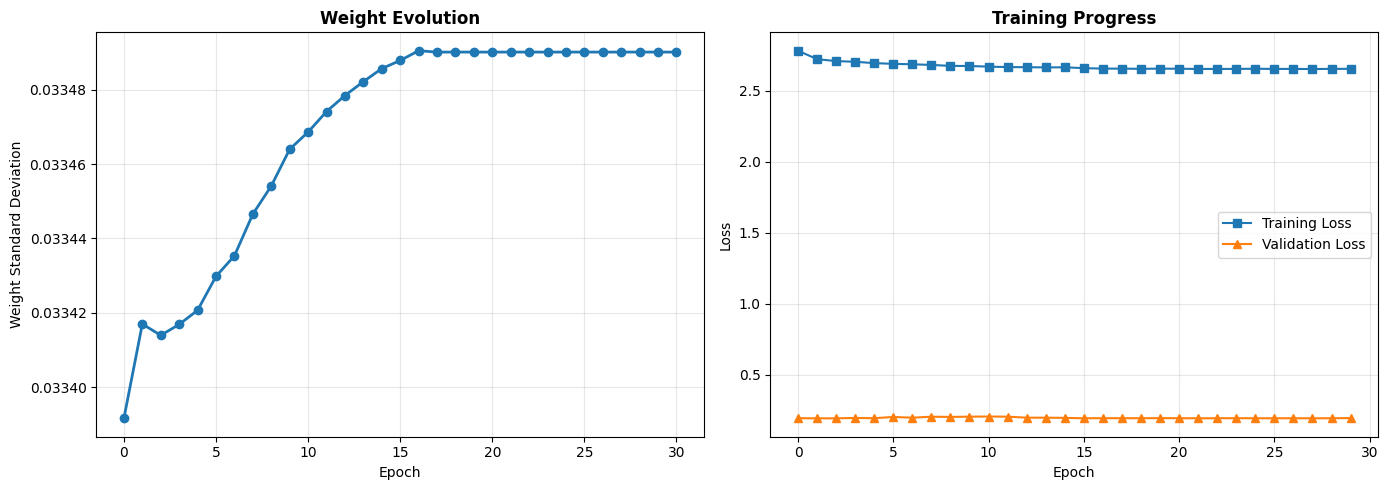


🎯 Final Results Summary:
   Dataset Size: 112,120 images
   Training Accuracy: 94.81%
   Validation Accuracy: 94.85%
   Test Accuracy: 94.86%



In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from datetime import datetime
import pickle
from tqdm.auto import tqdm
# ============================================================================
# BUILD AND TRAIN NEURAL NETWORK (WITH CLASS WEIGHTS)
# ============================================================================

print("="*70)
print("BUILDING NEURAL NETWORK")
print("="*70)

# Display dataset configuration
if SAMPLE_SIZE is not None:
    print(f"\n🎯 Training Dataset: {len(df):,} images (SAMPLE_SIZE={SAMPLE_SIZE})")
else:
    print(f"\n🎯 Training Dataset: {len(df):,} images (FULL DATASET)")

print(f"   Training samples: {len(X_train):,}")
print(f"   Validation samples: {len(X_val):,}")
print(f"   Test samples: {len(X_test):,}")

# Build model
model = keras.Sequential([
    layers.Input(shape=(1280,)),
    layers.Dense(512, activation='relu', name='hidden_layer_1'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu', name='hidden_layer_2'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='sigmoid', name='output_layer')
])

# Compute class weights to handle imbalance
print("\nComputing class weights to handle rare conditions...")
class_weights = {}
for i in range(NUM_CLASSES):
    neg = (y_train[:, i] == 0).sum()
    pos = (y_train[:, i] == 1).sum()
    if pos > 0:
        class_weights[i] = neg / pos  # Higher weight for rare classes
    else:
        class_weights[i] = 1.0

print("\nClass weights (higher = rarer condition):")
for i, condition in enumerate(CLASSES):
    print(f"  {condition:20s}: {class_weights[i]:.2f}x weight")

# Compile with LOWER learning rate to avoid quick convergence
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # Lower than default 0.001
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

model.summary()
print(f"\n✓ {model.count_params():,} trainable parameters\n")

# Train
print("="*70)
print("TRAINING NEURAL NETWORK (WITH CLASS BALANCING)")
print("="*70)
print("\nUsing class weights to learn rare conditions better...\n")

weight_history = []
initial_weights = model.get_layer('hidden_layer_1').get_weights()[0].copy()
weight_history.append(initial_weights.std())

class WeightTracker(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        weights = self.model.get_layer('hidden_layer_1').get_weights()[0]
        weight_history.append(weights.std())
        print(f"  Epoch {epoch+1}: Weight StdDev = {weights.std():.4f}, Loss = {logs['loss']:.4f}, Acc = {logs['binary_accuracy']:.2%}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,  # More epochs since lower learning rate
    batch_size=16,
    verbose=0,
    callbacks=[WeightTracker()],
    class_weight=class_weights  # Include class weights for balancing
)

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print(f"\nFinal Training Accuracy: {history.history['binary_accuracy'][-1]:.2%}")
print(f"Final Validation Accuracy: {history.history['val_binary_accuracy'][-1]:.2%}")

# Evaluate on test set
print("\n" + "="*70)
print("EVALUATING ON TEST SET")
print("="*70)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_accuracy:.2%}")
print(f"Test Loss: {test_loss:.4f}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(len(weight_history)), weight_history, marker='o', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Weight Standard Deviation')
ax1.set_title('Weight Evolution', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], marker='s', label='Training Loss')
ax2.plot(history.history['val_loss'], marker='^', label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training Progress', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
display(plt.gcf())
plt.close()

print("\n🎯 Final Results Summary:")
print(f"   Dataset Size: {len(df):,} images")
print(f"   Training Accuracy: {history.history['binary_accuracy'][-1]:.2%}")
print(f"   Validation Accuracy: {history.history['val_binary_accuracy'][-1]:.2%}")
print(f"   Test Accuracy: {test_accuracy:.2%}")
print("\n" + "="*70)

📊 COMPREHENSIVE MODEL EVALUATION

Calculating accuracy and AUC metrics for all 14 conditions...

Making predictions on test set...
✓ Predictions complete

OVERALL PERFORMANCE

✓ Exact Match Accuracy: 0.5401 (54.01%)
  (All 14 labels predicted correctly for an image)

✓ Hamming Accuracy: 0.9486 (94.86%)
  (Average accuracy across all labels)

✓ Overall AUC (Macro-Average): 0.5027
  (Average AUC across all 14 conditions)

PER-CLASS PERFORMANCE

Class-specific Accuracy and AUC-ROC scores:

 1. Atelectasis          - Acc: 0.8975 (89.75%)  AUC: 0.4955  (Pos: 2,299, Neg: 20,125)
 2. Cardiomegaly         - Acc: 0.9747 (97.47%)  AUC: 0.5015  (Pos: 567, Neg: 21,857)
 3. Effusion             - Acc: 0.8812 (88.12%)  AUC: 0.4987  (Pos: 2,663, Neg: 19,761)
 4. Infiltration         - Acc: 0.8259 (82.59%)  AUC: 0.5000  (Pos: 3,904, Neg: 18,520)
 5. Mass                 - Acc: 0.9497 (94.97%)  AUC: 0.5040  (Pos: 1,128, Neg: 21,296)
 6. Nodule               - Acc: 0.9430 (94.30%)  AUC: 0.5009  (Pos: 1,

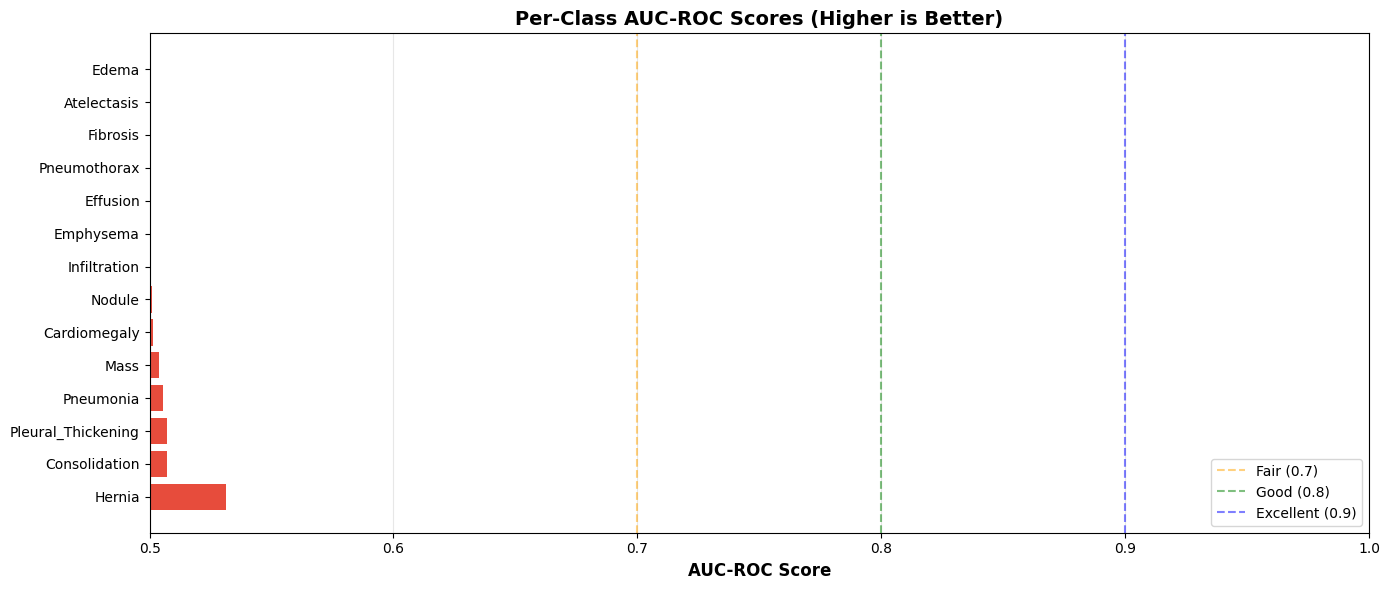

✓ Visualization complete!

🎯 FINAL EVALUATION SUMMARY

📊 Dataset Size: 22,424 test images

📈 Performance Metrics:
   • Exact Match Accuracy: 0.5401 (54.01%)
   • Hamming Accuracy: 0.9486 (94.86%)
   • Average Per-Class Accuracy: 0.9486 (94.86%)
   • Average AUC-ROC: 0.5027
   • Overall AUC (Macro): 0.5027

🏆 Best Performing Class: Hernia (AUC: 0.5313)
⚠️  Needs Improvement: Edema (AUC: 0.4920)

✅ EVALUATION COMPLETE!

📁 Results exported to 'results_df' DataFrame
   Use: display(results_df) to view the full table



,Class,Accuracy,AUC,Positive,Negative
0,Atelectasis,0.897476,0.495532,2299,20125
1,Cardiomegaly,0.974715,0.501469,567,21857
2,Effusion,0.881243,0.498690,2663,19761
3,Infiltration,0.825901,0.500027,3904,18520
4,Mass,0.949697,0.504024,1128,21296
5,Nodule,0.943007,0.500892,1278,21146
6,Pneumonia,0.986220,0.505425,309,22115
7,Pneumothorax,0.953889,0.498173,1034,21390
8,Consolidation,0.958036,0.507096,941,21483
9,Edema,0.980021,0.492019,448,21976


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

print("="*70)
print("📊 COMPREHENSIVE MODEL EVALUATION")
print("="*70)
print("\nCalculating accuracy and AUC metrics for all 14 conditions...\n")

# Disease classes
CLASSES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

# Make predictions on test set
print("Making predictions on test set...")
y_pred_proba = model.predict(X_test, verbose=0)
y_pred_binary = (y_pred_proba > 0.5).astype(int)
print("✓ Predictions complete\n")

# ============================================================================
# OVERALL METRICS
# ============================================================================

print("="*70)
print("OVERALL PERFORMANCE")
print("="*70)

# Overall accuracy (exact match - all labels correct)
exact_match_accuracy = accuracy_score(y_test, y_pred_binary)
print(f"\n✓ Exact Match Accuracy: {exact_match_accuracy:.4f} ({exact_match_accuracy*100:.2f}%)")
print("  (All 14 labels predicted correctly for an image)\n")

# Hamming accuracy (per-label accuracy)
hamming_accuracy = (y_test == y_pred_binary).mean()
print(f"✓ Hamming Accuracy: {hamming_accuracy:.4f} ({hamming_accuracy*100:.2f}%)")
print("  (Average accuracy across all labels)\n")

# Overall AUC (macro-average across all classes)
try:
    overall_auc = roc_auc_score(y_test, y_pred_proba, average='macro')
    print(f"✓ Overall AUC (Macro-Average): {overall_auc:.4f}")
    print("  (Average AUC across all 14 conditions)\n")
except ValueError as e:
    print(f"⚠️  Could not calculate overall AUC: {e}\n")
    overall_auc = None

# ============================================================================
# PER-CLASS METRICS
# ============================================================================

print("="*70)
print("PER-CLASS PERFORMANCE")
print("="*70)
print("\nClass-specific Accuracy and AUC-ROC scores:\n")

results = []

for idx, class_name in enumerate(CLASSES):
    y_true_class = y_test[:, idx]
    y_pred_class = y_pred_binary[:, idx]
    y_pred_proba_class = y_pred_proba[:, idx]

    # Accuracy for this class
    class_accuracy = accuracy_score(y_true_class, y_pred_class)

    # AUC for this class (if both positive and negative samples exist)
    try:
        class_auc = roc_auc_score(y_true_class, y_pred_proba_class)
    except ValueError:
        class_auc = None  # No positive or negative samples

    # Count positive samples
    n_positive = y_true_class.sum()
    n_negative = len(y_true_class) - n_positive

    results.append({
        'Class': class_name,
        'Accuracy': class_accuracy,
        'AUC': class_auc,
        'Positive': int(n_positive),
        'Negative': int(n_negative)
    })

    # Print formatted results
    auc_str = f"{class_auc:.4f}" if class_auc is not None else "N/A"
    print(f"{idx+1:2d}. {class_name:20s} - Acc: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)  AUC: {auc_str}  (Pos: {int(n_positive):,}, Neg: {int(n_negative):,})")

# Create DataFrame for easy viewing
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

avg_accuracy = results_df['Accuracy'].mean()
avg_auc = results_df[results_df['AUC'].notna()]['AUC'].mean()

print(f"\n✓ Average Accuracy (across all classes): {avg_accuracy:.4f} ({avg_accuracy*100:.2f}%)")
if not pd.isna(avg_auc):
    print(f"✓ Average AUC (across all classes): {avg_auc:.4f}\n")

# Best and worst performing classes
best_auc_idx = results_df[results_df['AUC'].notna()]['AUC'].idxmax()
worst_auc_idx = results_df[results_df['AUC'].notna()]['AUC'].idxmin()

print(f"📈 Best AUC: {results_df.loc[best_auc_idx, 'Class']} ({results_df.loc[best_auc_idx, 'AUC']:.4f})")
print(f"📉 Worst AUC: {results_df.loc[worst_auc_idx, 'Class']} ({results_df.loc[worst_auc_idx, 'AUC']:.4f})\n")

# ============================================================================
# VISUALIZE AUC SCORES
# ============================================================================

print("="*70)
print("VISUALIZATIONS")
print("="*70)
print("\nGenerating AUC bar chart...\n")

fig, ax = plt.subplots(figsize=(14, 6))

# Filter out None values
valid_results = results_df[results_df['AUC'].notna()].sort_values('AUC', ascending=False)

colors = ['#2ecc71' if auc >= 0.8 else '#f39c12' if auc >= 0.7 else '#e74c3c'
          for auc in valid_results['AUC']]

ax.barh(valid_results['Class'], valid_results['AUC'], color=colors)
ax.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='Fair (0.7)')
ax.axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Good (0.8)')
ax.axvline(x=0.9, color='blue', linestyle='--', alpha=0.5, label='Excellent (0.9)')
ax.set_xlabel('AUC-ROC Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class AUC-ROC Scores (Higher is Better)', fontsize=14, fontweight='bold')
ax.set_xlim(0.5, 1.0)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
display(fig)
plt.close()

print("✓ Visualization complete!")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*70)
print("🎯 FINAL EVALUATION SUMMARY")
print("="*70)
print(f"\n📊 Dataset Size: {len(y_test):,} test images")
print(f"\n📈 Performance Metrics:")
print(f"   • Exact Match Accuracy: {exact_match_accuracy:.4f} ({exact_match_accuracy*100:.2f}%)")
print(f"   • Hamming Accuracy: {hamming_accuracy:.4f} ({hamming_accuracy*100:.2f}%)")
print(f"   • Average Per-Class Accuracy: {avg_accuracy:.4f} ({avg_accuracy*100:.2f}%)")
if not pd.isna(avg_auc):
    print(f"   • Average AUC-ROC: {avg_auc:.4f}")
if overall_auc is not None:
    print(f"   • Overall AUC (Macro): {overall_auc:.4f}")

print(f"\n🏆 Best Performing Class: {results_df.loc[best_auc_idx, 'Class']} (AUC: {results_df.loc[best_auc_idx, 'AUC']:.4f})")
print(f"⚠️  Needs Improvement: {results_df.loc[worst_auc_idx, 'Class']} (AUC: {results_df.loc[worst_auc_idx, 'AUC']:.4f})")

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE!")
print("="*70)

# Export results to DataFrame for further analysis
print("\n📁 Results exported to 'results_df' DataFrame")
print("   Use: display(results_df) to view the full table\n")

display(results_df)